# EDA — raw ELS 유니버스 → 필터 퍼널 + 공정가비율·만기 분포

raw DART(`AUTO_CALL`/`UDLY_INFO`/`SCHD_INFO`) **원천 기준**으로 (1) 원래 총 상품 수, (2) 각 필터에서 얼마나 걸러지는지(퍼널), (3) 낙인배리어·가격이력 가용성으로 최종 몇 개가 남는지, (4) **공정가치 비율·만기 히스토그램**을 본다.

- 원천 **102,607건** → 6개 필터(3-기초자산·STEP·KRW·공정가비율·만기) → candidate **48,192건** → 데이터가용성 → 최종 **23,151건**.
- 최종 유니버스 = **낙인(KI)형 스텝다운 KRW 3-star ELS** (0_data `build_source` 와 동일 조건). candidate→최종의 최대 탈락은 **낙인배리어가 없는 노낙인 상품**(MC 엔진이 KI 배리어를 요구 → 구조적 제외)."

In [2]:
# ===== 필터 퍼널 (build_source 와 동일 조건, 순차 누적) =====
three = nu[nu == 3].index
steps, EN = [], []
def rec(ko, en, mask):
    steps.append((ko, int(mask.sum()))); EN.append(en)
m = pd.Series(True, index=ac.index)
rec("① 전체 AUTO_CALL", "All products", m)
m = m & ac["ITEM_CD"].isin(three);         rec("② 3-기초자산", "3 underlyings", m)
m = m & ac["OPT_TYPE"].eq("STEP");          rec("③ STEP(스텝다운)", "STEP", m)
m = m & ac["CUR_CD"].eq("KRW");             rec("④ KRW 통화", "KRW", m)
m = m & ac["fair"].between(0.70, 1.05);     rec("⑤ 공정가비율 0.70~1.05", "fair in [0.70, 1.05]", m)
m = m & ac["tenor"].between(0.5, 5.0);      rec("⑥ 만기 0.5~5년", "tenor in [0.5, 5]y", m)
cand = ac[m].copy()

fn = pd.DataFrame({"step": [s for s, _ in steps], "remaining": [v for _, v in steps]})
fn["dropped"] = (fn["remaining"].shift(1) - fn["remaining"]).fillna(0).astype(int)
fn["keep_%"] = (fn["remaining"] / N0 * 100).round(1)
print(fn.to_string(index=False))
print(f"\ncandidate(6개 필터 통과) = {len(cand):,} 건")

             step  remaining  dropped  keep_%
   ① 전체 AUTO_CALL     102607        0   100.0
         ② 3-기초자산      72822    29785    71.0
     ③ STEP(스텝다운)      57758    15064    56.3
         ④ KRW 통화      53563     4195    52.2
⑤ 공정가비율 0.70~1.05      48241     5322    47.0
      ⑥ 만기 0.5~5년      48192       49    47.0

candidate(6개 필터 통과) = 48,192 건


In [3]:
# ===== 데이터 가용성 (candidate → 최종): 낙인배리어·기초자산 가격이력·180일 vol/corr·행사가 =====
# 최대 탈락은 '낙인(KI) 배리어 없음' = 노낙인(KNCK_IN_YN=0) 상품 (MC 엔진이 KI 배리어를 요구 → 제외).
from module import mc as MC, features as F
mk = MC.load_market()
mapping, u3map, RET, strk_by, KRW = mk["mapping"], mk["u3map"], mk["RET"], mk["strk_by"], mk["KRW"]
sc = pd.read_csv(fm.RAW / "LAKE_V2_DART_SCHD_INFO.csv", low_memory=False)
sc1 = sc[sc.SCHD_TYPE == 1].sort_values(["ITEM_CD", "SEQ"])
barr_by = sc1.groupby("ITEM_CD")["BARR_1"].min() / 100

reason = collections.Counter(); npass = 0
for it, rw in cand.set_index("ITEM_CD").iterrows():
    B = barr_by.get(it)
    if pd.isna(B): reason["낙인(KI) 배리어 없음 = 노낙인 상품"] += 1; continue      # 최대 탈락(구조적 제외)
    ts = [mapping.get(x) for x in u3map.get(it, [])]; ts = [t for t in ts if t]
    if len(ts) != 3: reason["기초자산 티커 매핑 실패"] += 1; continue
    rets = [RET.get(t) for t in ts]
    if any(r is None for r in rets): reason["기초자산 가격이력 없음"] += 1; continue
    dt = rw.ISU_DT
    sigs = [F.vol180(r, dt) for r in rets]
    if any(pd.isna(sigs)): reason["180일 변동성 부족(<60거래일)"] += 1; continue
    if F.corr180(rets, dt) is None: reason["180일 상관 부족"] += 1; continue
    strikes = strk_by.get(it)
    if strikes is None or len(strikes) < 2 or any(pd.isna(strikes)): reason["행사가 스케줄 없음"] += 1; continue
    if pd.isna(rw.ANL_RTRN) or pd.isna(rw.tenor): reason["쿠폰/만기 결측"] += 1; continue
    if F.krw_beta(KRW.asof(dt).values) is None: reason["KRW 곡선 없음"] += 1; continue
    npass += 1

nki = int((cand.set_index("ITEM_CD")["KNCK_IN_YN"] == 1).sum())
print(f"candidate {len(cand):,} 중 낙인(KI)형 = {nki:,} / 노낙인 = {len(cand)-nki:,}")
print(f"candidate {len(cand):,} → 데이터가용성 통과(최종 학습 유니버스) = {npass:,} 건  ← 낙인형 스텝다운 KRW 3-star ELS")
print(f"가용성으로 탈락 = {len(cand) - npass:,} 건. 사유별:")
for k, v in reason.most_common():
    print(f"   {k:28s}: {v:,}")

candidate 48,192 중 낙인(KI)형 = 23,618 / 노낙인 = 24,574
candidate 48,192 → 데이터가용성 통과(최종 학습 유니버스) = 23,151 건  ← 낙인형 스텝다운 KRW 3-star ELS
가용성으로 탈락 = 25,041 건. 사유별:
   낙인(KI) 배리어 없음 = 노낙인 상품      : 24,573
   기초자산 티커 매핑 실패               : 401
   180일 변동성 부족(<60거래일)         : 53
   행사가 스케줄 없음                  : 9
   기초자산 가격이력 없음                : 5


## 그림 — 필터 퍼널 · 상품별 분류 · 공정가비율/만기 히스토그램
학술/PPT 사양(dpi 400·투명·콘텐츠밴드). 분류 히스토그램은 **raw 전체(All products)** 기준, 공정가비율/만기 히스토그램은 **KRW 3-기초자산 STEP** 유니버스(범위필터 전) 기준, 빨간 점선 = 필터 컷, 초록 음영 = 유지 구간.

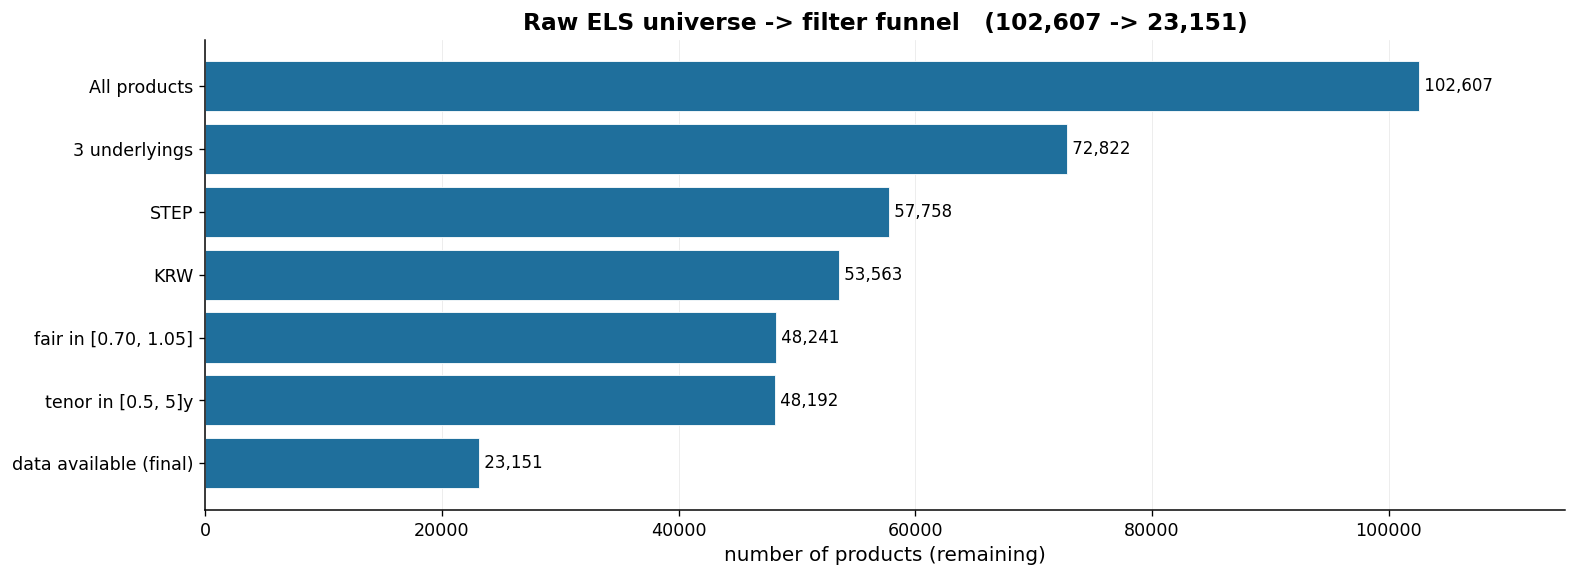

saved -> raw_filter_funnel.png


In [4]:
from util import plot as _plot   # 학술 rcParams
import matplotlib.pyplot as plt

labels = EN + ["data available (final)"]
vals = [v for _, v in steps] + [npass]
y = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(13.333, 5.0))
ax.barh(y, vals, color="#1f6f9c", edgecolor="white", linewidth=0.5)
ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v, i, f" {v:,}", va="center", fontsize=10)
ax.set_xlabel("number of products (remaining)")
ax.set_title(f"Raw ELS universe -> filter funnel   ({vals[0]:,} -> {vals[-1]:,})")
ax.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6)
ax.margins(x=0.12)
fig.tight_layout()
fig.savefig(fm.image("raw_filter_funnel"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print("saved ->", fm.image("raw_filter_funnel").name)

### 상품별 분류 히스토그램 — "All products" 는 무엇으로 이루어져 있나
퍼널 첫 칸(`All products`)을 **분류 기준별**로 쪼갠다. 파랑 = 퍼널 필터가 남기는 범주, 초록 = MC 엔진이 요구하는 범주(낙인 배리어), 회색 = 제외/설명용.
마지막 그림은 (기초자산수 x 옵션형 x 통화 x 낙인) **구조 클래스** 히스토그램 — 타깃 클래스가 raw 유니버스에서 차지하는 위치.

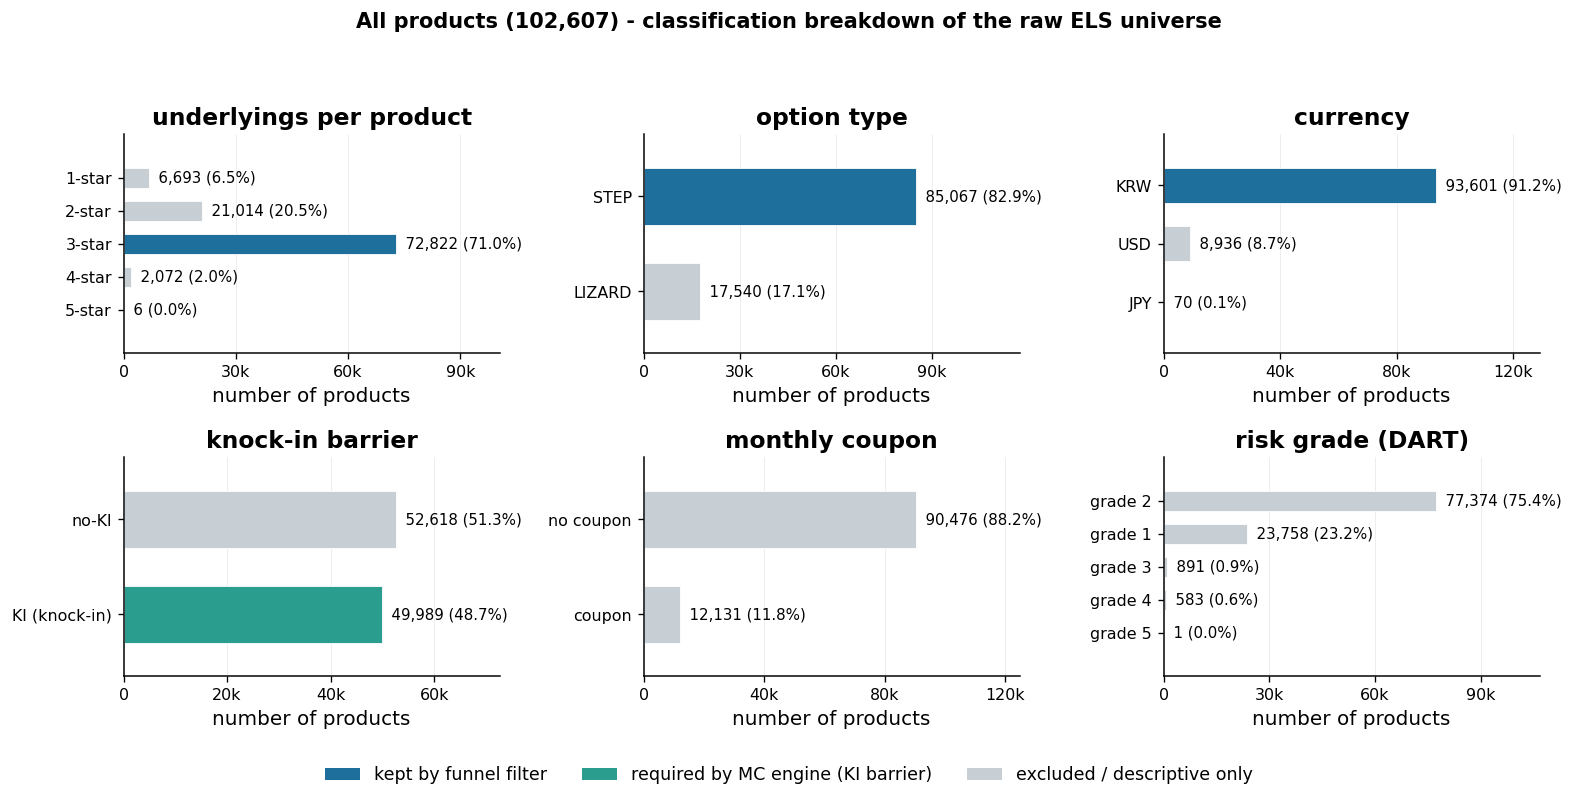

              dimension      category     n  share_% filter
underlyings per product        3-star 72822     71.0   kept
underlyings per product        2-star 21014     20.5       
underlyings per product        1-star  6693      6.5       
underlyings per product        4-star  2072      2.0       
underlyings per product        5-star     6      0.0       
            option type          STEP 85067     82.9   kept
            option type        LIZARD 17540     17.1       
               currency           KRW 93601     91.2   kept
               currency           USD  8936      8.7       
               currency           JPY    70      0.1       
       knock-in barrier         no-KI 52618     51.3       
       knock-in barrier KI (knock-in) 49989     48.7   kept
         monthly coupon     no coupon 90476     88.2       
         monthly coupon        coupon 12131     11.8       
      risk grade (DART)       grade 2 77374     75.4       
      risk grade (DART)       grade 1 23

In [5]:
# ===== 상품별 분류 히스토그램: raw 유니버스(All products)의 분류 기준별 구성 =====
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.patches import Patch

KEEP, AVAIL, DROP = "#1f6f9c", "#2a9d8f", "#c7ced4"   # 필터 유지 / MC엔진 요구 / 제외·설명용
nstar = ac["ITEM_CD"].map(nu).fillna(0).astype(int).astype(str) + "-star"
SPECS = [   # (패널 제목, 범주 시리즈, 남기는 범주, 강조색, 정렬순서(None=빈도순))
    ("underlyings per product", nstar, {"3-star"}, KEEP, sorted(nstar.unique())),
    ("option type", ac["OPT_TYPE"].fillna("(na)"), {"STEP"}, KEEP, None),
    ("currency", ac["CUR_CD"].fillna("(na)"), {"KRW"}, KEEP, None),
    ("knock-in barrier", ac["KNCK_IN_YN"].map({1: "KI (knock-in)", 0: "no-KI"}).fillna("(na)"),
     {"KI (knock-in)"}, AVAIL, None),
    ("monthly coupon", ac["CPN_YN"].map({1: "coupon", 0: "no coupon"}).fillna("(na)"), set(), DROP, None),
    ("risk grade (DART)", ac["RISK_GRADE"].map(lambda v: "(na)" if pd.isna(v) else f"grade {int(v)}"),
     set(), DROP, None),
]
kfmt = FuncFormatter(lambda v, _: f"{v/1000:g}k" if v >= 1000 else f"{v:g}")

fig, axes = plt.subplots(2, 3, figsize=(13.333, 6.6))
rows = []
for a, (title, ser, keep, kc, order) in zip(axes.ravel(), SPECS):
    vc = ser.value_counts()
    vc = vc.reindex(order) if order else vc.sort_values(ascending=False)
    y = np.arange(len(vc))
    a.barh(y, vc.values, height=0.6, color=[kc if k in keep else DROP for k in vc.index],
           edgecolor="white", linewidth=0.5)
    a.set_yticks(y); a.set_yticklabels(vc.index); a.invert_yaxis()
    for i, v in enumerate(vc.values):
        a.text(v, i, f"  {v:,} ({v / N0 * 100:.1f}%)", va="center", fontsize=9)
    a.set_title(title); a.set_xlabel("number of products")
    a.xaxis.set_major_formatter(kfmt); a.xaxis.set_major_locator(MaxNLocator(4))
    a.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6)
    a.margins(x=0.38, y=0.22); a.tick_params(labelsize=9.5)
    rows += [(title, k, v, round(v / N0 * 100, 1), "kept" if k in keep else "")
             for k, v in vc.sort_values(ascending=False).items()]

fig.legend(handles=[Patch(fc=KEEP, label="kept by funnel filter"),
                    Patch(fc=AVAIL, label="required by MC engine (KI barrier)"),
                    Patch(fc=DROP, label="excluded / descriptive only")],
           loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.015))
fig.suptitle(f"All products ({N0:,}) - classification breakdown of the raw ELS universe",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0.045, 1, 0.945))
fig.savefig(fm.image("raw_class_hist"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print(pd.DataFrame(rows, columns=["dimension", "category", "n", "share_%", "filter"]).to_string(index=False))
print("saved ->", fm.image("raw_class_hist").name)

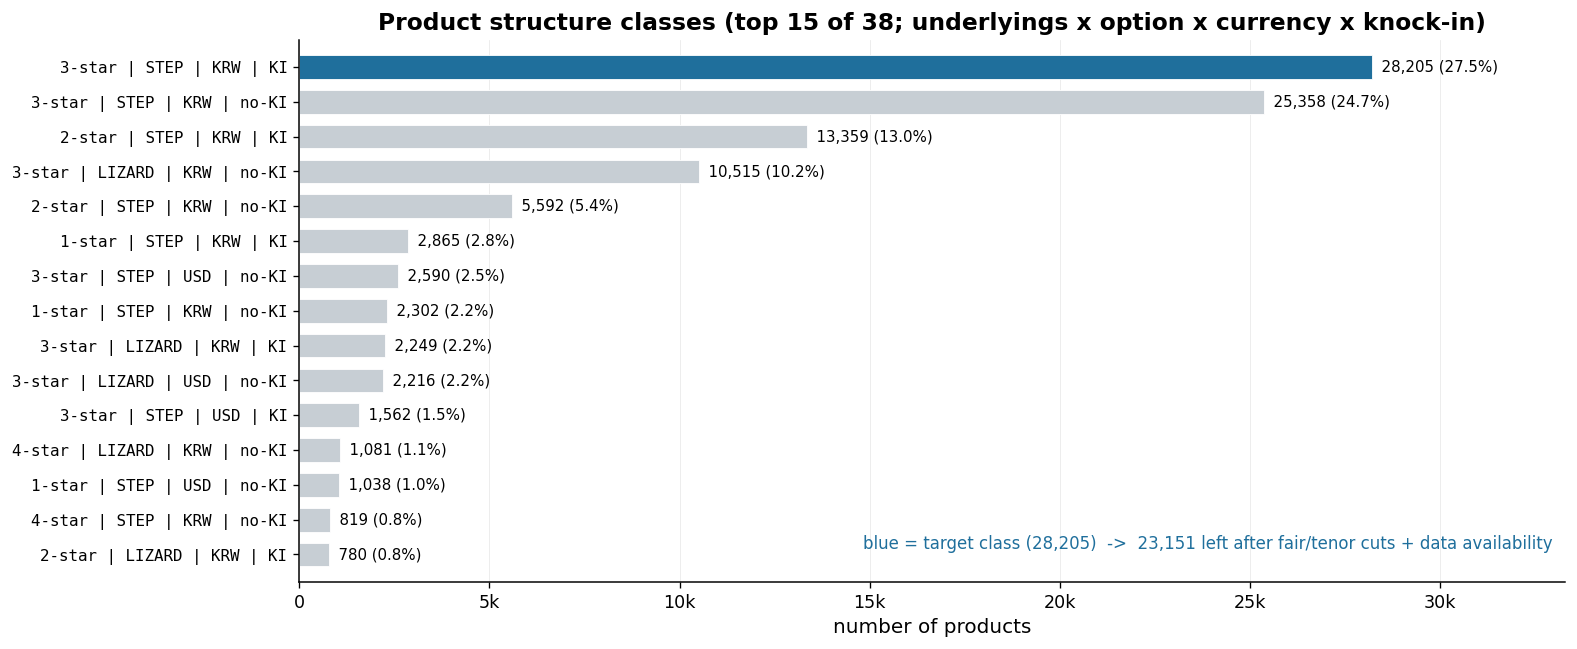

structure classes = 38 | top15 cumulative share = 98.0%
target class 3-star | STEP | KRW | KI = 28,205 (27.5% of raw)
saved -> raw_class_combo.png


In [ ]:
# ===== 구조 클래스(기초자산수 x 옵션형 x 통화 x 낙인) 히스토그램 — 타깃 클래스의 위치 =====
cls = (ac["ITEM_CD"].map(nu).fillna(0).astype(int).astype(str) + "-star | "
       + ac["OPT_TYPE"].fillna("?") + " | " + ac["CUR_CD"].fillna("?") + " | "
       + ac["KNCK_IN_YN"].map({1: "KI", 0: "no-KI"}).fillna("?"))
TARGET = "3-star | STEP | KRW | KI"          # = 최종 학습 유니버스의 구조 클래스
vc = cls.value_counts(); top = vc.head(15)

fig, ax = plt.subplots(figsize=(13.333, 5.6))
y = np.arange(len(top))
ax.barh(y, top.values, height=0.68, color=[KEEP if k == TARGET else DROP for k in top.index],yZ
        edgecolor="white", linewidth=0.5)
ax.set_yticks(y); ax.set_yticklabels(top.index, fontsize=9.5, family="monospace"); ax.invert_yaxis()
for i, v in enumerate(top.values):
    ax.text(v, i, f"  {v:,} ({v / N0 * 100:.1f}%)", va="center", fontsize=9)
ax.text(0.99, 0.06, f"blue = target class ({int((cls == TARGET).sum()):,})"
        f"  ->  {npass:,} left after fair/tenor cuts + data availability",
        transform=ax.transAxes, ha="right", fontsize=10, color=KEEP)
ax.set_xlabel("number of products"); ax.xaxis.set_major_formatter(kfmt)
ax.set_title(f"Product structure classes (top 15 of {vc.size}; underlyings x option x currency x knock-in)")
ax.grid(axis="x", color="#dddddd", lw=0.5, alpha=0.6); ax.margins(x=0.18, y=0.03)
fig.tight_layout()
fig.savefig(fm.image("raw_class_combo"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print(f"structure classes = {vc.size} | top15 cumulative share = {top.sum() / N0 * 100:.1f}%")
print(f"target class {TARGET} = {int((cls == TARGET).sum()):,} ({(cls == TARGET).mean() * 100:.1f}% of raw)")
print("saved ->", fm.image("raw_class_combo").name)

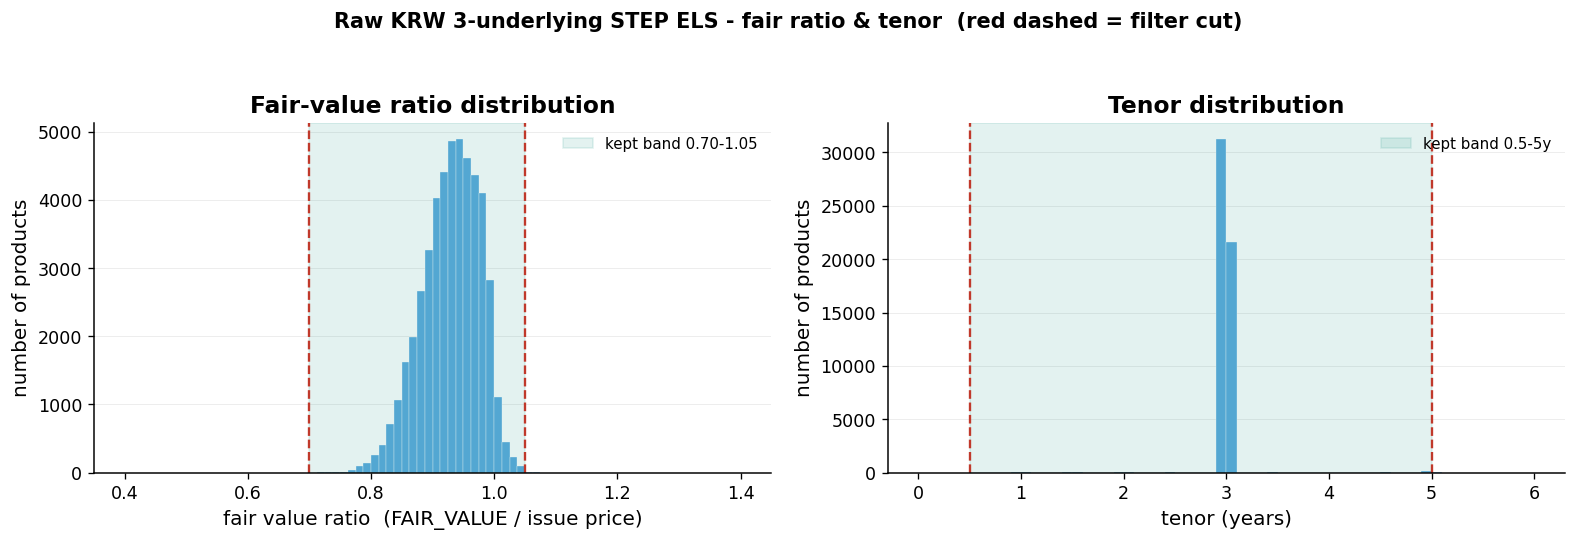

universe(KRW 3-underlying STEP) = 53,563 | fair median 0.927 | tenor median 3.00y
saved -> raw_fair_tenor_hist.png


In [ ]:
# 공정가비율 · 만기 히스토그램 (KRW 3-기초자산 STEP 유니버스, 범위필터 전)
uni = ac[ac["ITEM_CD"].isin(three) & ac["OPT_TYPE"].eq("STEP") & ac["CUR_CD"].eq("KRW")].copy()
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))

ax[0].hist(uni["fair"], bins=80, range=(0.4, 1.4), color="#5aa9dd", edgecolor="white", linewidth=0.2)
ax[0].axvspan(0.70, 1.05, color="#2a9d8f", alpha=0.13, label="kept band 0.70-1.05")
for x in (0.70, 1.05):
    ax[0].axvline(x, color="#c0392b", lw=1.4, ls="--")
ax[0].set_xlabel("fair value ratio  (FAIR_VALUE / issue price)")
ax[0].set_ylabel("number of products")
ax[0].set_title("Fair-value ratio distribution")
ax[0].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6); ax[0].legend(fontsize=9)

ax[1].hist(uni["tenor"], bins=60, range=(0, 6), color="#5aa9dd", edgecolor="white", linewidth=0.2)
ax[1].axvspan(0.5, 5.0, color="#2a9d8f", alpha=0.13, label="kept band 0.5-5y")
for x in (0.5, 5.0):
    ax[1].axvline(x, color="#c0392b", lw=1.4, ls="--")
ax[1].set_xlabel("tenor (years)"); ax[1].set_ylabel("number of products")
ax[1].set_title("Tenor distribution")
ax[1].grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6); ax[1].legend(fontsize=9)

fig.suptitle("Raw KRW 3-underlying STEP ELS - fair ratio & tenor  (red dashed = filter cut)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(fm.image("raw_fair_tenor_hist"), dpi=400, bbox_inches="tight", transparent=True); plt.show()
print(f"universe(KRW 3-underlying STEP) = {len(uni):,} | "
      f"fair median {uni['fair'].median():.3f} | tenor median {uni['tenor'].median():.2f}y")
print("saved ->", fm.image("raw_fair_tenor_hist").name)